<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%2007_c/Assignment_7c_Item_Response_Prediction_and_Click_Through_Rate_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Inference — Assignment7_c


This notebook provides complete, self-contained solutions to the two assigned problems:

1. **Bayesian Estimation of a User Ability Parameter from Item Responses**
2. **Bayesian Tracking of Click-Through Rates (CTR) via Conjugate Beta-Binomial Updates**




In [1]:
# Global setup: use a static-image renderer so that all Plotly figures
# are embedded as PNGs in the notebook output (renders correctly on GitHub
# and Colab, and does not depend on any external JS/CDN at view time).
import plotly.io as pio

pio.renderers.default = "png"

print("Plotly renderer set to:", pio.renderers.default)

Plotly renderer set to: png


# Q1. Bayesian Estimation of a User Ability Parameter from Item Responses

An online learning platform presents a user with a sequence of $n$ multiple-choice questions **one at a time**. Each question is either answered correctly or incorrectly, allowing the platform to update its estimate of the user's ability dynamically after every response.

Let $Y_i$ denote the user's response to the $i$-th item encountered:

$$Y_i=
\begin{cases}
1, & \text{if the user answers item } i \text{ correctly},\\
0, & \text{if the user answers item } i \text{ incorrectly}.
\end{cases}$$

The platform assumes that the probability of a correct response is governed by a two-parameter logistic (2PL) item response model. Specifically, conditional on the user's latent ability parameter $\Theta=\theta$, the response probability for item $i$ is:

$$P(Y_i=1\mid \Theta=\theta)=p_i(\theta)=\frac{1}{1+e^{-a_i(\theta-b_i)}},$$

where $a_i>0$ is the known discrimination parameter, and $b_i$ is the known difficulty parameter of item $i$.

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running vector of observed responses** up to the current step $k$ (where $1 \le k \le n$).

Before observing any responses, the platform initializes the user's latent ability estimate with a standard normal prior distribution:

$$f_{\Theta}^{(0)}(\theta) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{\theta^2}{2}\right) \quad \text{implying} \quad \Theta \sim \mathscr{N}(0,1).$$

As the user progresses, the posterior distribution at step $k-1$ serves as the prior distribution for step $k$.

---

### Tasks

1. **Visualizing the Mechanics:** Plot $P(Y_i=1\mid \Theta=\theta)$ vs $\theta$ using Plotly for two distinct values of $a_i$, where one of those $a_i$ values is paired with three different difficulty values of $b_i$. Interpret how moving $b_i$ shifts the curve horizontally.
2. **Sequential Likelihood Contribution:** Write down the likelihood contribution $L(y_k \mid \theta)$ of a *single* new response $y_k$ at step $k$, given the latent ability $\theta$. Then, write down the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.
3. **Mathematical Formulation of the Running Update:** Write down the recursive relationship for the posterior density at step $k$, denoted $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$, up to a proportionality constant, using the prior state $f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$ and the new observation $y_k$.
4. **Dynamic Shifting:** Explain how a correct answer ($y_k = 1$) to a highly difficult item (large $b_k$) mathematically shifts the peak of the running posterior density distribution relative to the previous step.
5. **Tracking Certainty and Sharpness:** Explain how the discrimination parameter $a_k$ of the current item alters the variance (or "sharpness") of the distribution during a running update. What happens when $a_k$ is very large versus very small?
6. **Numerical Implementation of a Running Grid:** Describe a algorithmic approach to numerically approximate and maintain this running posterior density function on a fixed grid of $\theta$-values. Explicitly state how you would perform the sequential normalization step computationally after an item is answered.
7. **Evaluating Convergence over the Timeline:** Suppose the user's true, hidden latent ability is $\theta_{\text{true}} = 0.75$. Write a Python script that extends your previous grid simulation to track the performance of the running estimators over a sequence of $n = 20$ items.
   * **Simulate Responses:** Dynamically generate the user's responses $y_k \in \{0, 1\}$ at each step by comparing a random draw from a Uniform distribution $U(0,1)$ against the true response probability $p_k(\theta_{\text{true}})$. Give each item a random difficulty $b_k \sim \mathscr{N}(0, 1)$ and a random discrimination $a_k \sim \text{Uniform}(0.5, 2.0)$.
   * **Track Estimators:** At each step $k$, calculate and store the running Posterior Mean ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$) and the running Maximum A Posteriori ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$) estimate.
   * **Visualize:** Use Plotly to create a single line chart showing the progression of both estimators from step $0$ to $20$. Add a static horizontal reference line at $y = 0.75$ representing $\theta_{\text{true}}$.
   * **Analysis:** Briefly explain how the distance between your estimators and $\theta_{\text{true}}$ changes as $k$ increases, and interpret what this implies about the platform's confidence in its measurement.


## Solution

### Task 1 — The 2PL Item Response Probability Model

Assuming that the item responses are conditionally independent given $\Theta=\theta$, the full-history likelihood is

$$
P(Y=y\mid \Theta=\theta)=\prod_{i=1}^n
\left[
p_i(\theta)
\right]^{y_i}
\left[
1-p_i(\theta)
\right]^{1-y_i},
$$

where

$$
p_i(\theta)
=\frac{1}{1+e^{-a_i(\theta-b_i)}}.
$$

The code below plots $p_i(\theta)$ for two discrimination values $a_i \in \{0.5, 1.5\}$, with $a_i = 1.5$ shown at three difficulty levels $b_i \in \{-2, 0, 2\}$.


In [2]:
!pip install -q "kaleido==0.2.1"

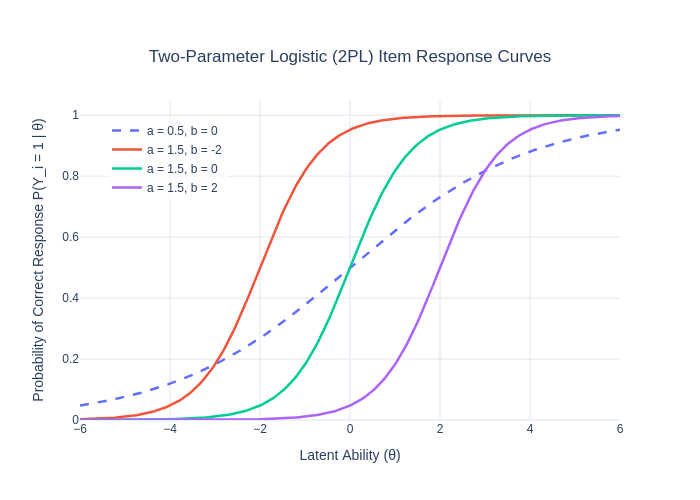

In [3]:
import numpy as np
import plotly.graph_objects as go

# Define the 2PL Item Response Function
def p_i(theta, a, b):
    return 1 / (1 + np.exp(-a * (theta - b)))

# Generate a range of latent ability values (theta)
theta_vals = np.linspace(-6, 6, 300)

# Define configurations to plot
# Two distinct a_i values (0.5 and 1.5)
# For a_i = 1.5, we include 3 different b_i values (-2, 0, 2)
curves = [
    {"a": 0.5, "b": 0, "line_style": "dash"},
    {"a": 1.5, "b": -2, "line_style": "solid"},
    {"a": 1.5, "b": 0, "line_style": "solid"},
    {"a": 1.5, "b": 2, "line_style": "solid"},
]

# Create the Plotly figure
fig = go.Figure()

for curve in curves:
    a = curve["a"]
    b = curve["b"]
    style = curve["line_style"]

    # Calculate probabilities
    p_vals = p_i(theta_vals, a, b)

    # Add trace to the plot
    fig.add_trace(go.Scatter(
        x=theta_vals,
        y=p_vals,
        mode='lines',
        name=f"a = {a}, b = {b}",
        line=dict(dash=style, width=2.5)
    ))

# Customize layout
fig.update_layout(
    title={
        'text': "Two-Parameter Logistic (2PL) Item Response Curves",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Latent Ability (θ)",
    yaxis_title="Probability of Correct Response P(Y_i = 1 | θ)",
    xaxis=dict(range=[-6, 6], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(range=[0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
    template="plotly_white",
    legend=dict(
        yanchor="top",
        y=0.95,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(255,255,255,0.8)"
    )
)

# Display the interactive plot
fig.show()


**Interpretation — effect of $b_i$.** The difficulty parameter $b_i$ is the value of $\theta$ at which the curve crosses probability $0.5$ (its inflection point). Increasing $b_i$ slides the entire S-shaped curve to the *right* along the $\theta$-axis without changing its shape, meaning a user now needs a *higher* ability to have the same chance of answering correctly — the item has become harder. Decreasing $b_i$ slides the curve *left*, making the item easier at any fixed ability level. The discrimination parameter $a_i$ instead controls the *steepness* of the curve at $\theta = b_i$: a larger $a_i$ (steeper curve) means the item is very good at separating users just below $b_i$ from users just above $b_i$, while a smaller $a_i$ (flatter curve) means the probability of success changes only gradually with ability, so the item is less informative about where exactly the user sits.

### Task 2 — Sequential Likelihood Contribution

**Single-response likelihood.** At step $k$, the newest response $y_k \in \{0,1\}$ is a Bernoulli trial with success probability $p_k(\theta) = \dfrac{1}{1+e^{-a_k(\theta - b_k)}}$. Its likelihood contribution is

$$L(y_k \mid \theta) = p_k(\theta)^{y_k}\,\big(1-p_k(\theta)\big)^{1-y_k}.$$

**Joint likelihood for the running history.** Assuming conditional independence of responses given $\Theta=\theta$, the joint likelihood of the entire running vector $\mathbf{y}^{(k)}=(y_1,\dots,y_k)$ is the product of the individual contributions:

$$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^{k} p_i(\theta)^{y_i}\big(1-p_i(\theta)\big)^{1-y_i}.$$

Unlike the Bernoulli/Beta case in Q2, here $p_i(\theta)$ depends on $\theta$ *nonlinearly* through the logistic link, and each item has its own $(a_i, b_i)$, so this product cannot be reduced to a low-dimensional sufficient statistic (such as a simple click count) — every individual item's parameters must be retained.

### Task 3 — Mathematical Formulation of the Running Update

At step $k$ (for $k = 1, \dots, n$), the current item response is $y_k$, and its likelihood contribution is:

$$L(y_k \mid \theta) = p_k(\theta)^{y_k} (1 - p_k(\theta))^{1 - y_k}$$

The sequential posterior density of $\Theta$ given the running response history vector $\mathbf{y}^{(k)}$ is updated recursively as follows:

$$f_{\Theta\mid\mathbf{Y}^{(k)}}(\theta\mid\mathbf{y}^{(k)}) = \frac{ \left[ p_k(\theta)^{y_k} (1 - p_k(\theta))^{1 - y_k} \right] f_{\Theta\mid\mathbf{Y}^{(k-1)}}(\theta\mid\mathbf{y}^{(k-1)}) }{ \int_{\mathbb R} \left[ p_k(s)^{y_k} (1 - p_k(s))^{1 - y_k} \right] f_{\Theta\mid\mathbf{Y}^{(k-1)}}(s\mid\mathbf{y}^{(k-1)})\,ds }$$

or, up to the proportionality constant asked for in the task,

$$f_{\Theta\mid\mathbf{Y}^{(k)}}(\theta\mid\mathbf{y}^{(k)}) \;\propto\; L(y_k\mid\theta)\cdot f_{\Theta\mid\mathbf{Y}^{(k-1)}}(\theta\mid\mathbf{y}^{(k-1)}).$$

**Definition of terms:**

* $f_{\Theta\mid\mathbf{Y}^{(k-1)}}(\theta\mid\mathbf{y}^{(k-1)})$ is the **prior density** for the current step (which is the posterior inherited from the previous step).
* For the very first item ($k=1$), the base prior is the initialized distribution:

$$f_{\Theta\mid\mathbf{Y}^{(0)}}(\theta\mid\mathbf{y}^{(0)}) = f_\Theta^{(0)}(\theta) = \frac{1}{\sqrt{2\pi}}\exp\left(-\frac{\theta^2}{2}\right)$$

* The denominator is the **local normalizing constant**, integrating out $\theta$ across the current likelihood-prior product so that the area under the new step-$k$ density curve integrates to $1$. Because the 2PL likelihood is not conjugate to the Normal prior, this integral has no closed form and must be evaluated numerically (Task 6).

### Task 4 — Dynamic Shifting

When a correct answer ($y_k=1$) is observed on a highly difficult item (large $b_k$), the likelihood factor multiplying the prior is $L(1\mid\theta) = p_k(\theta) = \dfrac{1}{1+e^{-a_k(\theta-b_k)}}$. As a function of $\theta$, this factor is small for $\theta \ll b_k$ and only rises toward $1$ once $\theta$ approaches or exceeds $b_k$ — i.e. it is heavily weighted toward *large* values of $\theta$.

Multiplying the previous posterior (prior for step $k$) by this rising, right-weighted likelihood curve suppresses the probability mass at low $\theta$ and reinforces mass at high $\theta$. After renormalizing, the new posterior's peak (mode) is pulled to the **right**, toward larger $\theta$, relative to the previous step. Intuitively: getting a *hard* question right is strong evidence of *high* ability, so the platform's belief about $\theta$ shifts upward — and the harder the item (the larger $b_k$), the more decisively a correct answer pulls the peak upward, because only sufficiently able users have a non-negligible chance of getting it right. (By symmetry, an incorrect answer, $y_k=0$, on an easy item — small $b_k$ — would similarly pull the peak sharply *downward*.)

### Task 5 — Tracking Certainty and Sharpness

The discrimination parameter $a_k$ controls how steeply the likelihood function $p_k(\theta)$ transitions from $0$ to $1$ around $\theta = b_k$, which directly governs how much the current observation *sharpens* (reduces the variance of) the running posterior:

* **Large $a_k$ (highly discriminative item):** $p_k(\theta)$ behaves almost like a step function around $b_k$. The likelihood factor $L(y_k\mid\theta)$ therefore strongly *penalizes* values of $\theta$ on the "wrong side" of $b_k$ (values inconsistent with the observed outcome) and leaves values on the "right side" almost untouched. Multiplying the prior by such a near-step-function likelihood removes a large amount of probability mass on one side, concentrating the posterior into a narrower region — i.e. it substantially **reduces the variance / increases the sharpness** of the posterior. Such an item is highly informative: a single response tightly pins down whether $\theta$ is above or below $b_k$.
* **Small $a_k$ (weakly discriminative item):** $p_k(\theta)$ changes only gradually with $\theta$, so the likelihood factor is nearly flat (close to constant) across a wide range of $\theta$. Multiplying the prior by a nearly-flat function barely reshapes it, so the posterior after the update looks almost the same as the prior — the update **contributes very little new information**, and the variance shrinks only marginally.

In short, $a_k$ acts like the "precision" or "informativeness" of item $k$: as $a_k \to \infty$ each response becomes maximally informative (drastic sharpening / variance reduction), while as $a_k \to 0$ each response becomes essentially uninformative (the posterior is left almost unchanged from the prior).

### Task 6 — Numerical Implementation of a Running Grid

Because the 2PL likelihood is not conjugate to a Normal prior, the posterior has no closed form and must be tracked numerically. A standard **grid-based sequential Bayesian update** algorithm is:

1. **Discretize the parameter space.** Choose a fixed, sufficiently fine and wide grid of ability values $\theta_1, \theta_2, \dots, \theta_M$ (e.g. `theta = np.linspace(-5, 5, 500)`), spanning the region where the prior/posterior mass is expected to lie.
2. **Initialize.** Evaluate the initial prior density on the grid: `posterior = norm.pdf(theta, 0, 1)`. This array represents (an unnormalized-but-already-normalized-by-construction) discretized version of $f_\Theta^{(0)}(\theta)$.
3. **Sequential update loop.** For each new item $k = 1, 2, \dots, n$ with known $(a_k, b_k)$ and observed response $y_k$:
   * Evaluate the item-response curve on the grid: `p = p_i(theta, a_k, b_k)`.
   * Evaluate the likelihood contribution pointwise on the grid: `likelihood = p**y_k * (1-p)**(1-y_k)`.
   * Form the unnormalized posterior by pointwise multiplication: `posterior = posterior * likelihood`.
   * **Sequential normalization step:** numerically integrate the unnormalized array over the grid (e.g. via the trapezoidal rule, `Z = np.trapezoid(posterior, theta)`) and divide every grid value by this constant: `posterior = posterior / Z`. This rescales the array so it again integrates to $1$ over $\theta$, turning it back into a valid probability density before it becomes the prior for step $k+1$.
4. **Extract estimates whenever needed.** From the current normalized array:
   * Posterior mean: `theta_bayes = np.trapezoid(theta * posterior, theta)`.
   * MAP estimate: `theta_map = theta[np.argmax(posterior)]`.
5. **Repeat** steps 3–4 for every subsequent item, always using the *previous step's normalized posterior array* as the new prior — this is exactly what makes the procedure "running" / online rather than a single batch computation.

The grid never changes shape or size across steps; only the *values* stored at each grid point are updated and renormalized, which keeps memory and computation cost constant per step ($O(M)$), regardless of how many items $n$ have been seen.

### Task 7 — Evaluating Convergence over the Timeline

The script below (a) reproduces the manual 4-item grid update from Task 6 as a sanity check, and (b) runs the full $n=20$-item convergence simulation with random item parameters, tracking $\widehat\theta_{\mathrm{Bayes}}^{(k)}$ and $\widehat\theta_{\mathrm{MAP}}^{(k)}$ against the true ability $\theta_{\text{true}} = 0.75$.

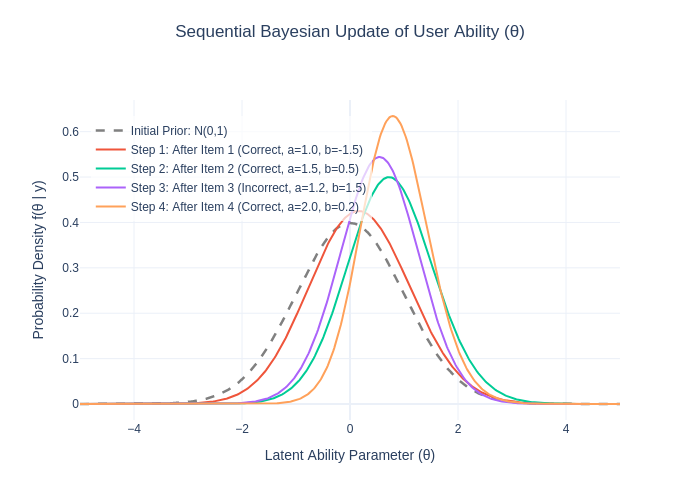

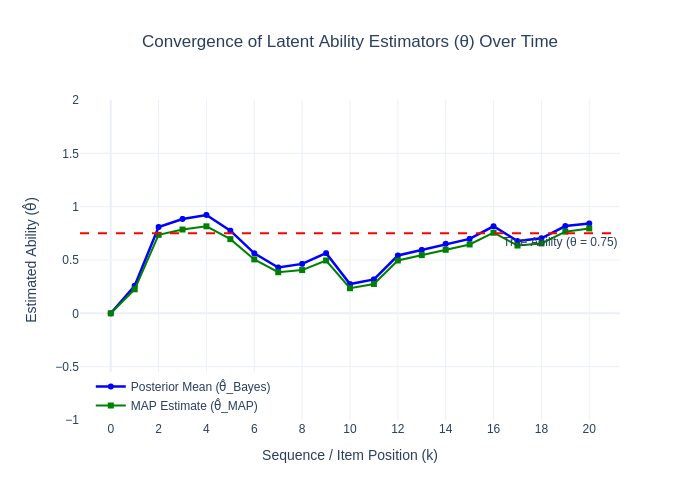

Final Posterior Mean estimate after 20 items: 0.8423
Final MAP estimate after 20 items:            0.7958
True ability theta_true:                              0.7500


In [4]:
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go

# =====================================================================
# PART 1: SEQUENTIAL BAYESIAN UPDATE (MANUAL 4-ITEM SIMULATION)
# =====================================================================

# 1. Define a fine grid of latent ability values (theta)
theta = np.linspace(-5, 5, 500)

# 2. Initialize the prior distribution: Standard Normal N(0, 1)
prior = stats.norm.pdf(theta, 0, 1)

# 3. Define the Item Response Function (2PL Model)
def p_i(theta, a, b):
    return 1 / (1 + np.exp(-a * (theta - b)))

# 4. Define the manual simulated sequence of item encounters
running_items = [
    {"a": 1.0, "b": -1.5, "y": 1},  # Step 1: Got an easy item correct
    {"a": 1.5, "b": 0.5,  "y": 1},  # Step 2: Got a medium-hard item correct
    {"a": 1.2, "b": 1.5,  "y": 0},  # Step 3: Got a very hard item incorrect
    {"a": 2.0, "b": 0.2,  "y": 1}   # Step 4: Got a highly discriminative item correct
]

# Create the first Plotly figure
fig1 = go.Figure()

# Add the initial Prior distribution trace
fig1.add_trace(go.Scatter(
    x=theta,
    y=prior,
    mode='lines',
    name='Initial Prior: N(0,1)',
    line=dict(dash='dash', width=2.5, color='gray')
))

# Run the sequential update loop
current_posterior = prior.copy()

for idx, item in enumerate(running_items):
    a = item["a"]
    b = item["b"]
    y = item["y"]

    # Calculate item response probability across the grid
    prob = p_i(theta, a, b)

    # Calculate the likelihood contribution of this response
    likelihood = (prob ** y) * ((1 - prob) ** (1 - y))

    # Posterior proportional to Prior * Likelihood
    current_posterior = current_posterior * likelihood

    # Numerically normalize the density curve using the trapezoidal rule
    integral = np.trapezoid(current_posterior, theta)
    current_posterior /= integral

    # Format trace labels
    result_text = "Correct" if y == 1 else "Incorrect"
    trace_name = f"Step {idx+1}: After Item {idx+1} ({result_text}, a={a}, b={b})"

    # Add the current posterior step to the plot
    fig1.add_trace(go.Scatter(
        x=theta,
        y=current_posterior,
        mode='lines',
        name=trace_name,
        line=dict(width=2)
    ))

# Customize layout for Figure 1
fig1.update_layout(
    title={
        'text': "Sequential Bayesian Update of User Ability (θ)",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Latent Ability Parameter (θ)",
    yaxis_title="Probability Density f(θ | y)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        yanchor="top", y=0.95, xanchor="left", x=0.02,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

# Display the first plot
fig1.show()


# =====================================================================
# PART 2: PERFORMANCE TRACKING & CONVERGENCE TIMELINE (20 ITEMS)
# =====================================================================

# Set random seed for reproducibility of the random items/responses
np.random.seed(42)

# 1. Setup Simulation Parameters
theta_true = 0.75
n_items = 20
theta_grid = np.linspace(-5, 5, 1000)  # Finer grid for tracking accuracy

# 2. Generate Random Item Characteristics
a_params = np.random.uniform(0.5, 2.0, size=n_items)
b_params = np.random.normal(0, 1, size=n_items)

# 3. Initialize Tracking Arrays (Step 0 = Initial Prior State)
running_bayes = [0.0]
running_map = [0.0]
steps = list(range(n_items + 1))

# Initialize prior density distribution: N(0, 1)
current_posterior_sim = stats.norm.pdf(theta_grid, 0, 1)

# 4. Run the 20-item Sequential Simulation loop
for k in range(n_items):
    a_k = a_params[k]
    b_k = b_params[k]

    # Compute true response probability at true theta
    prob_true = p_i(theta_true, a_k, b_k)

    # Simulate stochastically generated user response y_k
    y_k = 1 if np.random.uniform(0, 1) < prob_true else 0

    # Calculate likelihood curve across grid
    prob_grid = p_i(theta_grid, a_k, b_k)
    likelihood = (prob_grid ** y_k) * ((1 - prob_grid) ** (1 - y_k))

    # Update and normalize
    current_posterior_sim = current_posterior_sim * likelihood
    integral_sim = np.trapezoid(current_posterior_sim, theta_grid)
    current_posterior_sim /= integral_sim

    # Compute point estimates
    theta_bayes_k = np.trapezoid(theta_grid * current_posterior_sim, theta_grid)
    theta_map_k = theta_grid[np.argmax(current_posterior_sim)]

    # Store estimates
    running_bayes.append(theta_bayes_k)
    running_map.append(theta_map_k)

# 5. Create the second Plotly figure
fig2 = go.Figure()

# Add True Ability Reference Horizontal Line
fig2.add_hline(
    y=theta_true,
    line_dash="dash",
    line_color="red",
    line_width=2,
    annotation_text=f"True Ability (θ = {theta_true})",
    annotation_position="bottom right"
)

# Add Posterior Mean Trace
fig2.add_trace(go.Scatter(
    x=steps, y=running_bayes,
    mode='lines+markers',
    name='Posterior Mean (θ̂_Bayes)',
    line=dict(color='blue', width=2.5),
    marker=dict(size=6)
))

# Add MAP Trace
fig2.add_trace(go.Scatter(
    x=steps, y=running_map,
    mode='lines+markers',
    name='MAP Estimate (θ̂_MAP)',
    line=dict(color='green', width=2),
    marker=dict(size=6, symbol='square')
))

# Customize Layout for Figure 2
fig2.update_layout(
    title={
        'text': "Convergence of Latent Ability Estimators (θ) Over Time",
        'y': 0.93, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Sequence / Item Position (k)",
    yaxis_title="Estimated Ability (θ̂)",
    xaxis=dict(tickmode='linear', tick0=0, dtick=2),
    yaxis=dict(range=[-1, 2]),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.15, xanchor="left", x=0.02)
)

# Display the second plot
fig2.show()

print(f"Final Posterior Mean estimate after {n_items} items: {running_bayes[-1]:.4f}")
print(f"Final MAP estimate after {n_items} items:            {running_map[-1]:.4f}")
print(f"True ability theta_true:                              {theta_true:.4f}")


**Analysis.** Both $\widehat\theta_{\mathrm{Bayes}}^{(k)}$ and $\widehat\theta_{\mathrm{MAP}}^{(k)}$ start at (or near) $0$ — the mean/mode of the $\mathscr N(0,1)$ prior — and, on average, move progressively closer to $\theta_{\text{true}}=0.75$ as more items ($k$) are observed, although the path is not perfectly monotonic because each new item injects fresh randomness (a "lucky" or "unlucky" response can temporarily push the estimate away before subsequent items correct it). Early on, with only one or two responses observed, the likelihood is based on very little evidence, so the posterior is still strongly influenced by the prior and the estimates can swing noticeably from item to item. As $k$ grows, the *accumulated* likelihood from many items dominates the fixed prior, the posterior progressively concentrates (narrows) around the true value, and the two estimators increasingly agree with each other and settle near $\theta_{\text{true}}$. This reflects the platform gaining **confidence** in its measurement over time: each additional response sharpens (reduces the spread of) the posterior, so later estimates are not only more accurate on average but also more *stable* — an interval/estimate reported after 20 items is far more trustworthy than one reported after just 1 or 2.

# Q2. Bayesian Tracking of Click-Through Rates (CTR) via Conjugate Beta-Binomial Updates

An e-commerce platform wants to optimize its recommendation engine by dynamically estimating the click-through rate (CTR) of a newly launched advertisement. Since user traffic arrives continuously, the platform updates its belief about the advertisement's performance **one impression at a time** rather than waiting for large batch updates.

Let $\Theta = \theta$ represent the true, hidden conversion rate (probability of a click) of the advertisement, where $\theta \in [0, 1]$.

Let $Y_k$ denote a single user's interaction with the advertisement at time step $k$:

$$Y_k =
\begin{cases}
1, & \text{if the user clicks the advertisement}, \\
0, & \text{if the user does not click the advertisement}.
\end{cases}$$

The platform assumes that conditional on the true conversion rate $\Theta = \theta$, each user interaction is an independent Bernoulli trial:

$$P(Y_k = 1 \mid \Theta = \theta) = \theta$$

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running vector of observed user interactions** up to the current impression step $k$ (where $1 \le k \le n$).

Before observing any data, the platform assigns a flexible **Beta distribution** as the initial prior over the unknown parameter $\Theta$:

$$f_{\Theta}^{(0)}(\theta) = \frac{1}{\mathrm{B}(\alpha_0, \beta_0)} \theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1} \quad \text{implying} \quad \Theta \sim \text{Beta}(\alpha_0, \beta_0)$$

where $\mathrm{B}(\cdot, \cdot)$ is the Beta function acting as the normalizing constant. Under a sequential framework, the posterior distribution at step $k-1$ serves directly as the prior distribution for step $k$.

---

**Tasks**

**1. Structural Probability and Properties**
Plot the probability density function (PDF) of a $\text{Beta}(\alpha, \beta)$ distribution using Plotly for three distinct parameter pairs:

* Uninformative state: $(\alpha=1, \beta=1)$
* Right-skewed state: $(\alpha=2, \beta=8)$
* Left-skewed state: $(\alpha=8, \beta=2)$

Interpret how changing the balance between $\alpha$ and $\beta$ shifts the center of mass of the density function over the domain $[0, 1]$.

**2. Sequential Likelihood and Joint History**

Write down the mathematical likelihood contribution $L(y_k \mid \theta)$ of a *single* isolated response $y_k$ at step $k$, given the click probability $\theta$. Following this, express the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.

**3. Closed-Form Analytical Updates (Conjugacy)**

Using Bayes' Theorem, derive the recursive algebraic relationship for the posterior density at step $k$, denoted as $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$. Prove analytically that the posterior remains in the Beta family (**Beta-Binomial Conjugacy**) by explicitly writing down the closed-form update parameters $\alpha_k$ and $\beta_k$ as simple arithmetic updates of $\alpha_{k-1}$, $\beta_{k-1}$, and $y_k$. Also compute the **Posterior Mean** of the latent parameter $\Theta$ at time step $k$ (i.e. $\mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}=\mathbf{y}^{(k)}]$).

**4. Dynamic Shifting Mechanics**

Explain how an observed click ($y_k = 1$) vs. a non-click ($y_k = 0$) shifts the peak of the running density distribution mathematically. Contrast this analytical framework against non-conjugate setups (such as the 2PL IRT model) where numerical grid integration is strictly required.

**5. Running Point Estimators**

State the exact closed-form equations used to evaluate the following point estimates at step $k$ directly from the updated shape parameters $\alpha_k$ and $\beta_k$:

* **Running Posterior Mean** ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$)
* **Running Maximum A Posteriori** ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$)

**6. Performance Tracking and Convergence Analysis**

Suppose the advertisement's true, hidden click-through rate is $\theta_{\text{true}} = 0.35$. Write a Python script to track the performance of your closed-form sequential estimators over a timeline of $n = 100$ impressions:

* **Initialize State:** Set the base prior parameters to $\alpha_0 = 1, \beta_0 = 1$ (representing uniform initial uncertainty).
* **Simulate Responses:** Dynamically generate user responses $y_k \in \{0, 1\}$ at each step by comparing a random draw from a Uniform distribution $U(0,1)$ against $\theta_{\text{true}}$.
* **Track Estimators:** Loop through each step, update $\alpha_k$ and $\beta_k$ analytically, and store the computed values for $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$.
* **Visualize:** Use Plotly to create a single line chart showing the progression of both estimators from step $0$ to $100$. Add a static horizontal reference line at $y = 0.35$ representing $\theta_{\text{true}}$.
* **Analysis:** Explain how the distance between your estimators and $\theta_{\text{true}}$ responds as the sampling size $k$ approaches $100$. What does this imply about the accumulation of evidence over time relative to the choice of the initial prior?


## Solution

### Task 1 — Structural Probability and Properties

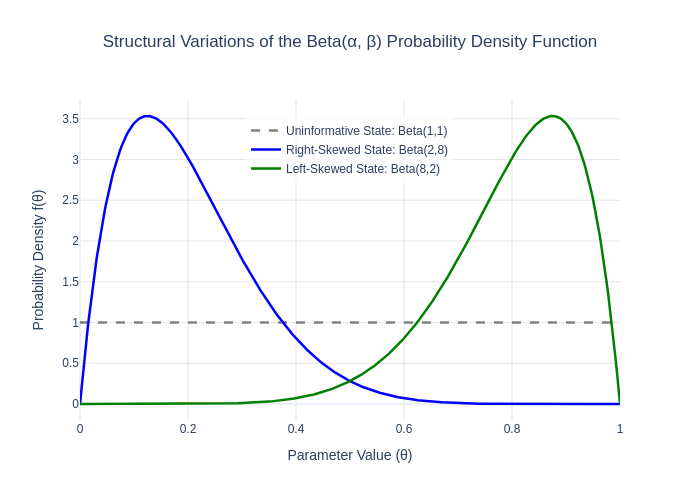

In [5]:
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go

# 1. Generate a dense grid of points over the bounded domain [0, 1]
theta_grid = np.linspace(0, 1, 500)

# 2. Define the three distinct parameter configurations
beta_configs = [
    {"alpha": 1, "beta": 1, "name": "Uninformative State: Beta(1,1)", "color": "gray", "dash": "dash"},
    {"alpha": 2, "beta": 8, "name": "Right-Skewed State: Beta(2,8)", "color": "blue", "dash": "solid"},
    {"alpha": 8, "beta": 2, "name": "Left-Skewed State: Beta(8,2)", "color": "green", "dash": "solid"}
]

# 3. Create the Plotly figure
fig = go.Figure()

for config in beta_configs:
    a = config["alpha"]
    b = config["beta"]

    # Calculate the exact analytical probability density function (PDF)
    pdf_vals = stats.beta.pdf(theta_grid, a, b)

    # Add trace to the plot
    fig.add_trace(go.Scatter(
        x=theta_grid,
        y=pdf_vals,
        mode='lines',
        name=config["name"],
        line=dict(color=config["color"], dash=config["dash"], width=2.5)
    ))

# 4. Customize layout and design
fig.update_layout(
    title={
        'text': "Structural Variations of the Beta(α, β) Probability Density Function",
        'y': 0.93,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title="Parameter Value (θ)",
    yaxis_title="Probability Density f(θ)",
    xaxis=dict(range=[0, 1], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(gridcolor='rgba(0,0,0,0.1)'),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        yanchor="top",
        y=0.95,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

# Display the interactive plot
fig.show()


**Interpretation.** The mean of a $\text{Beta}(\alpha,\beta)$ distribution is $\dfrac{\alpha}{\alpha+\beta}$, so the *balance* between $\alpha$ and $\beta$ directly controls where the density's center of mass sits on $[0,1]$:

* $\text{Beta}(1,1)$: $\alpha=\beta$, mean $=0.5$, and the density is exactly flat (uniform) — the "uninformative" state, expressing no preference for any value of $\theta$.
* $\text{Beta}(2,8)$: $\beta > \alpha$, mean $= 0.2$, so the mass is pulled toward $0$ — a **right-skewed** density concentrated at low click-rate values (long tail toward $1$).
* $\text{Beta}(8,2)$: $\alpha > \beta$, mean $= 0.8$, so the mass is pulled toward $1$ — a **left-skewed** density concentrated at high click-rate values (long tail toward $0$).

In general, increasing $\alpha$ relative to $\beta$ shifts the center of mass toward $1$ (more prior "successes"), while increasing $\beta$ relative to $\alpha$ shifts it toward $0$ (more prior "failures"); the *sum* $\alpha+\beta$ meanwhile controls how concentrated (peaked) the density is around that mean, with larger sums giving a narrower, more confident distribution.

### Task 2 — Sequential Likelihood and Joint History

**1. Single Isolated Response Likelihood**

At any specific impression step $k$, the user interaction $y_k \in \{0, 1\}$ is modeled as an independent Bernoulli trial conditional on the true click probability $\theta$. The mathematical likelihood contribution $L(y_k \mid \theta)$ of this single outcome is expressed as:

$$L(y_k \mid \theta) = \theta^{y_k} (1 - \theta)^{1 - y_k}$$

* If the user clicks ($y_k = 1$), the expression simplifies to $\theta^1 (1-\theta)^0 = \theta$.
* If the user does not click ($y_k = 0$), the expression simplifies to $\theta^0 (1-\theta)^1 = 1 - \theta$.

**2. Joint Likelihood Function for the Running History**

Assuming that individual user interactions are conditionally independent given the underlying conversion parameter $\Theta = \theta$, the joint likelihood function for the entire running history vector $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ is the product of the individual step likelihoods up to time step $k$:

$$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^k \theta^{y_i} (1 - \theta)^{1 - y_i} = \theta^{\sum_{i=1}^k y_i} (1 - \theta)^{\sum_{i=1}^k (1 - y_i)}$$

Letting $C_k = \sum_{i=1}^k y_i$ represent the total running count of clicks, and $k - C_k = \sum_{i=1}^k (1 - y_i)$ represent the total running count of non-clicks, the joint history likelihood simplifies compactly to:

$$L(\mathbf{y}^{(k)} \mid \theta) = \theta^{C_k} (1 - \theta)^{k - C_k}$$

Note that, unlike the 2PL model of Q1, this joint likelihood depends on the data *only* through the single sufficient statistic $C_k$ (the running click count) — the order of clicks/non-clicks is irrelevant.

### Task 3 — Closed-Form Analytical Updates (Conjugacy)

**1. Recursive Relationship via Bayes' Theorem**

In a running update framework, the posterior distribution at step $k-1$ acts directly as the prior distribution for step $k$. Applying Bayes' Theorem sequentially, the posterior density after observing the newest single event $y_k$ is:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) = \frac{L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})}{\int_{0}^{1} L(y_k \mid s) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(s \mid \mathbf{y}^{(k-1)})\,ds}$$

Dropping the denominator (the local normalizing constant) yields the recursive formulation up to a proportionality constant:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$$

**2. Analytical Proof of Beta-Binomial Conjugacy**

Assume that the prior density at the start of step $k$ (which is the posterior inherited from step $k-1$) belongs to the Beta family with shape parameters $\alpha_{k-1}$ and $\beta_{k-1}$:

$$f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)}) = \frac{1}{\mathrm{B}(\alpha_{k-1}, \beta_{k-1})} \theta^{\alpha_{k-1} - 1} (1 - \theta)^{\beta_{k-1} - 1} \propto \theta^{\alpha_{k-1} - 1} (1 - \theta)^{\beta_{k-1} - 1}$$

Substituting the single isolated response likelihood from Task 2 into the proportional recursive framework:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto \left[ \theta^{y_k} (1 - \theta)^{1 - y_k} \right] \cdot \left[ \theta^{\alpha_{k-1} - 1} (1 - \theta)^{\beta_{k-1} - 1} \right]$$

Combining like algebraic bases by summing their exponential powers:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto \theta^{(\alpha_{k-1} + y_k) - 1} \cdot (1 - \theta)^{(\beta_{k-1} + 1 - y_k) - 1}$$

Because the resulting kernel $\theta^{\text{power}_1 - 1}(1-\theta)^{\text{power}_2 - 1}$ matches the exact structural form of a Beta probability density function, the posterior is proven to remain inside the Beta family — this is the Beta-Binomial **conjugacy** property.

**3. Closed-Form Arithmetic Update Parameters**

Equating the exponent powers directly reveals that the new analytical state parameters $(\alpha_k, \beta_k)$ are simple deterministic linear updates of the previous state:

$$\alpha_k = \alpha_{k-1} + y_k \qquad\qquad \beta_k = \beta_{k-1} + (1 - y_k)$$

Including the exact beta normalization constant, the explicit closed-form posterior density at step $k$ is:

$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) = \frac{1}{\mathrm{B}(\alpha_k, \beta_k)} \theta^{\alpha_k - 1} (1 - \theta)^{\beta_k - 1}, \qquad \Theta \mid \mathbf{y}^{(k)} \sim \text{Beta}(\alpha_k,\beta_k)$$

**4. Posterior Mean at Step $k$**

Since the posterior distribution at step $k$ is $\text{Beta}(\alpha_k, \beta_k)$, its expectation follows the standard formula for a Beta distribution's mean:

$$\mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}=\mathbf{y}^{(k)}] = \frac{\alpha_k}{\alpha_k + \beta_k}$$

Expanding this using the recursive updates, with $\alpha_k = \alpha_0 + C_k$ and $\beta_k = \beta_0 + (k-C_k)$ (where $C_k=\sum_{i=1}^k y_i$ is the running click count):

$$\mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}=\mathbf{y}^{(k)}] = \frac{\alpha_0 + C_k}{(\alpha_0 + \beta_0) + k}$$

**Interpretation.** This closed form is a weighted average of the prior belief ($\alpha_0,\beta_0$) and the empirical evidence ($C_k$ clicks out of $k$ impressions). As $k \to \infty$, the prior's contribution ($\alpha_0,\beta_0$) becomes negligible next to $C_k$ and $k$, and the formula collapses to the empirical click-through rate $C_k/k$ — the maximum-likelihood estimate.

### Task 4 — Dynamic Shifting Mechanics

**Effect of a click vs. a non-click.** From $\alpha_k=\alpha_{k-1}+y_k$ and $\beta_k=\beta_{k-1}+(1-y_k)$:

* A **click** ($y_k=1$) increments $\alpha$ by $1$ and leaves $\beta$ unchanged: $\alpha_k=\alpha_{k-1}+1,\ \beta_k=\beta_{k-1}$. Since the mode of a $\text{Beta}(\alpha,\beta)$ with $\alpha,\beta>1$ is $\dfrac{\alpha-1}{\alpha+\beta-2}$, increasing $\alpha$ while holding $\beta$ fixed strictly increases this ratio — the peak of the density shifts **rightward** (toward higher $\theta$), reflecting increased belief in a higher click-through rate.
* A **non-click** ($y_k=0$) increments $\beta$ by $1$ and leaves $\alpha$ unchanged: $\alpha_k=\alpha_{k-1},\ \beta_k=\beta_{k-1}+1$. This decreases the mode ratio, shifting the peak **leftward** (toward lower $\theta$), reflecting increased belief in a lower click-through rate.

In both cases the *total* concentration $\alpha_k+\beta_k$ also grows by exactly $1$ with every observation, so each update simultaneously shifts the peak (in the direction of the observed outcome) **and** narrows the distribution slightly (increasing certainty), regardless of which outcome occurred.

**Contrast with non-conjugate setups (2PL IRT model).** In the Beta-Binomial model, because the Bernoulli likelihood and Beta prior are conjugate, every update reduces to two integer/scalar additions ($\alpha_k=\alpha_{k-1}+y_k$, $\beta_k=\beta_{k-1}+(1-y_k)$) — the entire posterior *shape* is captured exactly by two numbers, with no need to ever evaluate an integral or store a density array. In the 2PL item-response model of Q1, the logistic likelihood is *not* conjugate to the Normal prior: multiplying a Normal density by a logistic-shaped likelihood does not yield another distribution from a named closed-form family. Consequently there, the posterior has no finite-dimensional sufficient statistic, and the platform is forced to represent the entire density numerically on a grid and explicitly perform a numerical integration (e.g. the trapezoidal rule) at every single update step just to renormalize it. The Beta-Binomial case is thus dramatically more efficient computationally and easier to reason about analytically — the price paid is that this convenient exact conjugacy only exists for special likelihood/prior pairings such as Bernoulli–Beta.

### Task 5 — Running Point Estimators

Both point estimates follow directly, in closed form, from the updated Beta shape parameters $\alpha_k,\beta_k$ — no numerical integration or grid search is required:

**Running Posterior Mean (Bayes estimate, minimizing expected squared-error loss):**

$$\widehat{\theta}_{\mathrm{Bayes}}^{(k)} = \mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}=\mathbf{y}^{(k)}] = \frac{\alpha_k}{\alpha_k+\beta_k}$$

**Running Maximum A Posteriori (mode of the Beta density):**

$$\widehat{\theta}_{\mathrm{MAP}}^{(k)} = \frac{\alpha_k - 1}{\alpha_k + \beta_k - 2}, \qquad \text{valid when } \alpha_k>1 \text{ and } \beta_k>1.$$

When $\alpha_k \le 1$ or $\beta_k \le 1$, the $\text{Beta}(\alpha_k,\beta_k)$ density is monotonic (or U-shaped) rather than unimodal in the interior, and the mode instead lies at a boundary: $\widehat{\theta}_{\mathrm{MAP}}^{(k)} = 0$ if $\alpha_k \le \beta_k$ (density decreasing / weighted toward $0$), and $\widehat{\theta}_{\mathrm{MAP}}^{(k)} = 1$ if $\alpha_k > \beta_k$ (weighted toward $1$). This boundary case only matters near the very start of the sequence, since after even one click and one non-click both $\alpha_k,\beta_k \geq 2 > 1$ under the $\text{Beta}(1,1)$ initialization used in Task 6.

### Task 6 — Performance Tracking and Convergence Analysis

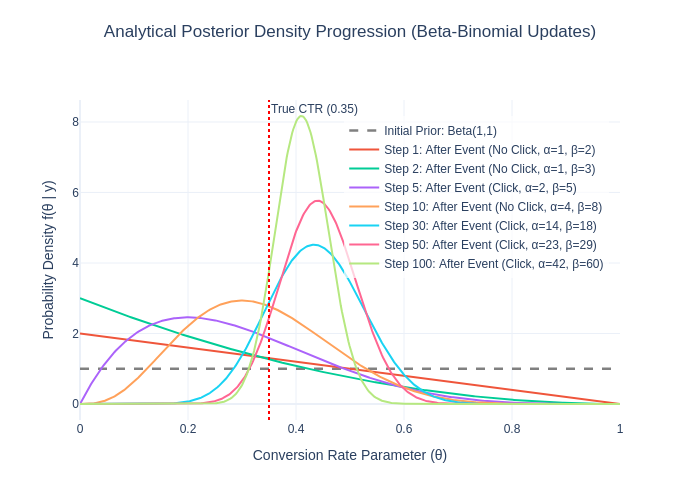

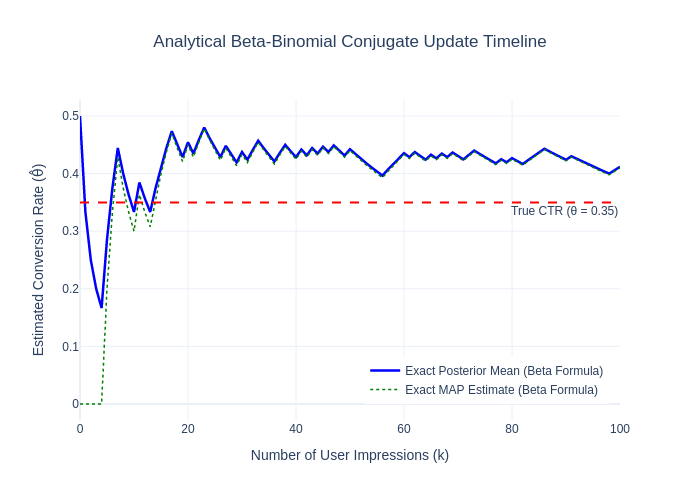

Final Posterior Mean estimate after 100 impressions: 0.4118
Final MAP estimate after 100 impressions:            0.4100
True CTR theta_true:                                              0.3500
Final posterior parameters: alpha_100 = 42, beta_100 = 60


In [6]:
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# CONFIGURATION & PARAMETERS
# =====================================================================
theta_true = 0.35  # The true click-through rate of the advertisement (35%)
n_impressions = 100
steps = list(range(n_impressions + 1))

# Initialize Beta Prior Parameters (Prior: Uniform distribution Beta(1,1))
alpha_param = 1
beta_param = 1

# Setup grid for plotting probability density curves (Domain: 0 to 1)
theta_grid = np.linspace(0, 1, 500)

# Define specific milestone steps where we want to capture the full curve shape
milestones = [0, 1, 2, 5, 10, 30, 50, 100]

# Tracking arrays for point estimates
running_bayes = [alpha_param / (alpha_param + beta_param)]
running_map = [0.0]  # Mode of Uniform(0,1)

# Initialize Figure 1 for the probability density progression curves
fig1 = go.Figure()

# Plot the initial Prior Beta(1, 1) distribution curve
prior_density = stats.beta.pdf(theta_grid, alpha_param, beta_param)
fig1.add_trace(go.Scatter(
    x=theta_grid, y=prior_density, mode='lines',
    name='Initial Prior: Beta(1,1)',
    line=dict(dash='dash', width=2.5, color='gray')
))

# =====================================================================
# RUNNING ANALYTICAL UPDATE LOOP
# =====================================================================
for k in range(1, n_impressions + 1):
    # Simulate a user action stochastically based on true CTR
    y_k = 1 if np.random.uniform(0, 1) < theta_true else 0

    # EXACT CLOSED-FORM CONJUGATE UPDATE RULES:
    alpha_param += y_k
    beta_param += (1 - y_k)

    # Calculate exact point estimates directly from analytical formulas
    theta_bayes_k = alpha_param / (alpha_param + beta_param)

    # Guard formula for mode when alpha or beta <= 1
    if alpha_param > 1 and beta_param > 1:
        theta_map_k = (alpha_param - 1) / (alpha_param + beta_param - 2)
    else:
        theta_map_k = 0.0 if alpha_param <= beta_param else 1.0

    running_bayes.append(theta_bayes_k)
    running_map.append(theta_map_k)

    # If the current step hits one of our milestone checkpoints, capture its PDF
    if k in milestones:
        # Evaluate exact density curve across the grid analytically
        density_k = stats.beta.pdf(theta_grid, alpha_param, beta_param)
        result_text = "Click" if y_k == 1 else "No Click"

        fig1.add_trace(go.Scatter(
            x=theta_grid, y=density_k, mode='lines',
            name=f"Step {k}: After Event ({result_text}, α={alpha_param}, β={beta_param})",
            line=dict(width=2)
        ))

# =====================================================================
# VISUALIZE FIGURE 1: POSTERIOR DISTRIBUTION PROGRESSION
# =====================================================================
# Add True CTR vertical line to see where the density curves are peaking
fig1.add_vline(
    x=theta_true, line_dash="dot", line_color="red", line_width=2,
    annotation_text=f"True CTR ({theta_true})", annotation_position="top right"
)

fig1.update_layout(
    title={
        'text': "Analytical Posterior Density Progression (Beta-Binomial Updates)",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Conversion Rate Parameter (θ)",
    yaxis_title="Probability Density f(θ | y)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        yanchor="top", y=0.95, xanchor="right", x=0.98,
        bgcolor="rgba(255,255,255,0.7)"
    )
)
fig1.show()

# =====================================================================
# VISUALIZE FIGURE 2: CONVERGENCE TIMELINE
# =====================================================================
fig2 = go.Figure()

# Add True CTR Reference Line
fig2.add_hline(
    y=theta_true, line_dash="dash", line_color="red", line_width=2,
    annotation_text=f"True CTR (θ = {theta_true})", annotation_position="bottom right"
)

# Add Posterior Mean Trace
fig2.add_trace(go.Scatter(
    x=steps, y=running_bayes, mode='lines',
    name='Exact Posterior Mean (Beta Formula)',
    line=dict(color='blue', width=2.5)
))

# Add MAP Trace
fig2.add_trace(go.Scatter(
    x=steps, y=running_map, mode='lines',
    name='Exact MAP Estimate (Beta Formula)',
    line=dict(color='green', width=1.5, dash='dot')
))

fig2.update_layout(
    title={
        'text': "Analytical Beta-Binomial Conjugate Update Timeline",
        'y': 0.93, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Number of User Impressions (k)",
    yaxis_title="Estimated Conversion Rate (θ̂)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="bottom", y=0.05, xanchor="right", x=0.98)
)
fig2.show()

print(f"Final Posterior Mean estimate after {n_impressions} impressions: {running_bayes[-1]:.4f}")
print(f"Final MAP estimate after {n_impressions} impressions:            {running_map[-1]:.4f}")
print(f"True CTR theta_true:                                              {theta_true:.4f}")
print(f"Final posterior parameters: alpha_100 = {alpha_param}, beta_100 = {beta_param}")


**Analysis.** Both $\widehat\theta_{\mathrm{Bayes}}^{(k)}$ and $\widehat\theta_{\mathrm{MAP}}^{(k)}$ start at the prior's mean/mode under $\text{Beta}(1,1)$ ($0.5$ and $0.0$ respectively) and are visibly noisy in the first few impressions, since with only a handful of observed clicks/non-clicks the uninformative prior still carries meaningful weight relative to the sparse evidence — a single early click or non-click can swing the running estimate substantially. As $k$ grows toward $100$, both estimators trend toward $\theta_{\text{true}}=0.35$ and their fluctuations shrink: because $\widehat\theta_{\mathrm{Bayes}}^{(k)} = \dfrac{\alpha_0+C_k}{(\alpha_0+\beta_0)+k}$, the fixed prior contribution $\alpha_0=\beta_0=1$ is progressively diluted by the growing denominator $k$, so the estimate is increasingly dominated by the empirical click rate $C_k/k$; likewise $\alpha_k+\beta_k=(\alpha_0+\beta_0)+k$ grows linearly in $k$, which shrinks the posterior variance of a Beta distribution (which scales roughly as $O(1/k)$) and therefore tightens both the Bayes-mean and MAP estimates around the true value. This illustrates the general Bayesian principle that, regardless of the initial prior chosen, sufficient accumulated evidence eventually **overwhelms** the prior's influence — a weak/uninformative prior like $\text{Beta}(1,1)$ is washed out especially quickly, and by $k=100$ impressions the platform's estimate is essentially the empirical CTR, held with much tighter (higher-confidence) uncertainty than it had after only a handful of impressions.